## 1: Configuration and Data Download

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1.1: Configuration ---
print("--- Starting Step 1: Configuration and Data Download ---")
# Define the ticker symbol for FTSE 100 (standard Yahoo Finance ticker)
ticker_symbol = "^FTSE"

# Define the date range for your project (2019-2024 as per your scope)
# 'end_date' is exclusive, so set it to the beginning of the next year to include full 2024 data.
start_date = "2019-01-01"
end_date = "2025-01-01"

print(f"Configured to download: {ticker_symbol}")
print(f"Date range: from {start_date} to {end_date}")

# --- Step 1.2: Download Historical Data ---
print(f"\n--- Attempting to download data for {ticker_symbol} ---")

# Download data
ftse_data = yf.download(ticker_symbol, start=start_date, end=end_date)

# Check if data was actually downloaded
if ftse_data.empty:
    print(f"WARNING: No data found for {ticker_symbol} in the specified range. Please check ticker or dates.")
    # We won't exit, but the next steps might fail if ftse_data is empty.

print("Data downloaded successfully!")
print("\n--- Raw DataFrame Head (first 5 rows) ---")
print(ftse_data.head().to_markdown(index=True, numalign="left", stralign="left")) # Using to_markdown for clear output
print("\n--- Raw DataFrame Information (dtypes, non-null counts) ---")
ftse_data.info()
print("\n--- Raw DataFrame Columns ---")
print(ftse_data.columns.tolist())

--- Starting Step 1: Configuration and Data Download ---
Configured to download: ^FTSE
Date range: from 2019-01-01 to 2025-01-01

--- Attempting to download data for ^FTSE ---


/tmp/ipython-input-1816778813.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ftse_data = yf.download(ticker_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Data downloaded successfully!

--- Raw DataFrame Head (first 5 rows) ---
| Date                | ('Close', '^FTSE')   | ('High', '^FTSE')   | ('Low', '^FTSE')   | ('Open', '^FTSE')   | ('Volume', '^FTSE')   |
|:--------------------|:---------------------|:--------------------|:-------------------|:--------------------|:----------------------|
| 2019-01-02 00:00:00 | 6734.2               | 6753.3              | 6599.5             | 6728.1              | 6.14252e+08           |
| 2019-01-03 00:00:00 | 6692.7               | 6753.1              | 6685.1             | 6734.2              | 6.74099e+08           |
| 2019-01-04 00:00:00 | 6837.4               | 6850.4              | 6692.5             | 6692.7              | 6.39137e+08           |
| 2019-01-07 00:00:00 | 6810.9               | 6874.1              | 6778               | 6837.4              | 7.3656e+08            |
| 2019-01-08 00:00:00 | 6861.6               | 6901.5              | 6804.9             | 6810.9              |

## 2: Column Flattening, Renaming, and Index Formatting

In [2]:
print("--- Starting Step 2: Column Flattening, Renaming, and Index Formatting ---")
ftse_data.index = pd.to_datetime(ftse_data.index)
print("DataFrame index ensured to be DatetimeIndex.")


# --- Step 2.2: Flatten Multi-Index Columns ---
print("\n--- Flattening multi-index columns ---")
# Create new column names by taking the first element of each tuple
# E.g., ('Close', '^FTSE') becomes 'Close'
new_columns = [col[0] for col in ftse_data.columns]
ftse_data.columns = new_columns
print("Columns flattened successfully.")


# --- Step 2.3: Rename 'Close' to 'Adj Close' for Consistency ---
print("\n--- Renaming 'Close' column to 'Adj Close' ---")
if 'Close' in ftse_data.columns:
    ftse_data = ftse_data.rename(columns={'Close': 'Adj Close'})
    print("'Close' column renamed to 'Adj Close'.")
else:
    print("Warning: 'Close' column not found after flattening. Please check previous steps.")


# --- Display Results of Step 2 ---
print("\n--- DataFrame Head after Flattening and Renaming ---")
print(ftse_data.head().to_markdown(index=True, numalign="left", stralign="left"))
print("\n--- DataFrame Information after Flattening and Renaming ---")
ftse_data.info()
print("\n--- DataFrame Columns after Flattening and Renaming ---")
print(ftse_data.columns.tolist())

--- Starting Step 2: Column Flattening, Renaming, and Index Formatting ---
DataFrame index ensured to be DatetimeIndex.

--- Flattening multi-index columns ---
Columns flattened successfully.

--- Renaming 'Close' column to 'Adj Close' ---
'Close' column renamed to 'Adj Close'.

--- DataFrame Head after Flattening and Renaming ---
| Date                | Adj Close   | High   | Low    | Open   | Volume      |
|:--------------------|:------------|:-------|:-------|:-------|:------------|
| 2019-01-02 00:00:00 | 6734.2      | 6753.3 | 6599.5 | 6728.1 | 6.14252e+08 |
| 2019-01-03 00:00:00 | 6692.7      | 6753.1 | 6685.1 | 6734.2 | 6.74099e+08 |
| 2019-01-04 00:00:00 | 6837.4      | 6850.4 | 6692.5 | 6692.7 | 6.39137e+08 |
| 2019-01-07 00:00:00 | 6810.9      | 6874.1 | 6778   | 6837.4 | 7.3656e+08  |
| 2019-01-08 00:00:00 | 6861.6      | 6901.5 | 6804.9 | 6810.9 | 6.51977e+08 |

--- DataFrame Information after Flattening and Renaming ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 

## 3: Data Cleaning and Calculating Log Returns

In [3]:
print("--- Starting Step 3: Data Cleaning and Calculating Log Returns ---")

# --- Step 3.1: Final Data Inspection and Cleaning for Missing Values ---
print("\n--- Checking for and handling missing values ---")
print("Missing values before cleaning:")
print(ftse_data.isnull().sum().to_markdown(numalign="left", stralign="left"))
print("\nApplying forward-fill (ffill) to handle missing values...")
ftse_data.fillna(method='ffill', inplace=True)

ftse_data.dropna(inplace=True)
print("Missing values after ffill and dropna:")
print(ftse_data.isnull().sum().to_markdown(numalign="left", stralign="left"))
print(f"Shape of data after cleaning: {ftse_data.shape}")


# --- Step 3.2: Verify Index Sorting and Uniqueness ---
print("\n--- Verifying and sorting index, handling duplicates ---")
ftse_data.sort_index(inplace=True) # Ensure the index is chronologically sorted
if not ftse_data.index.is_unique:
    print("WARNING: Duplicate dates found in the index. Handling by keeping the last entry.")
    ftse_data = ftse_data.loc[~ftse_data.index.duplicated(keep='last')]
    print(f"Shape of data after handling duplicates: {ftse_data.shape}")
else:
    print("Index is unique (no duplicate dates found).")
print("Index sorted successfully.")


# --- Step 3.3: Calculate Log Returns ---
print("\n--- Calculating Log Returns ---")
ftse_data['Log_Returns'] = np.log(ftse_data['Adj Close'] / ftse_data['Adj Close'].shift(1))

print("Dropping first row with NaN Log_Returns...")
ftse_data.dropna(subset=['Log_Returns'], inplace=True)


# --- Display Results of Step 3 ---
print("\n--- DataFrame Head with 'Adj Close' and new 'Log_Returns' column ---")
print(ftse_data[['Adj Close', 'Log_Returns']].head().to_markdown(index=True, numalign="left", stralign="left"))
print("\n--- DataFrame Information after Log Returns Calculation ---")
ftse_data.info()
print(f"\nTotal data points for returns after calculation: {ftse_data.shape[0]}")

--- Starting Step 3: Data Cleaning and Calculating Log Returns ---

--- Checking for and handling missing values ---
Missing values before cleaning:
|           | 0   |
|:----------|:----|
| Adj Close | 0   |
| High      | 0   |
| Low       | 0   |
| Open      | 0   |
| Volume    | 0   |

Applying forward-fill (ffill) to handle missing values...
Missing values after ffill and dropna:
|           | 0   |
|:----------|:----|
| Adj Close | 0   |
| High      | 0   |
| Low       | 0   |
| Open      | 0   |
| Volume    | 0   |
Shape of data after cleaning: (1514, 5)

--- Verifying and sorting index, handling duplicates ---
Index is unique (no duplicate dates found).
Index sorted successfully.

--- Calculating Log Returns ---
Dropping first row with NaN Log_Returns...

--- DataFrame Head with 'Adj Close' and new 'Log_Returns' column ---
| Date                | Adj Close   | Log_Returns   |
|:--------------------|:------------|:--------------|
| 2019-01-03 00:00:00 | 6692.7      | -0.00618164 

/tmp/ipython-input-3768320126.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ftse_data.fillna(method='ffill', inplace=True)


## 4: Data Visualization and Preparation for Modeling

--- Starting Step 4: Data Visualization and Preparation for Modeling ---

--- Generating Visualizations ---


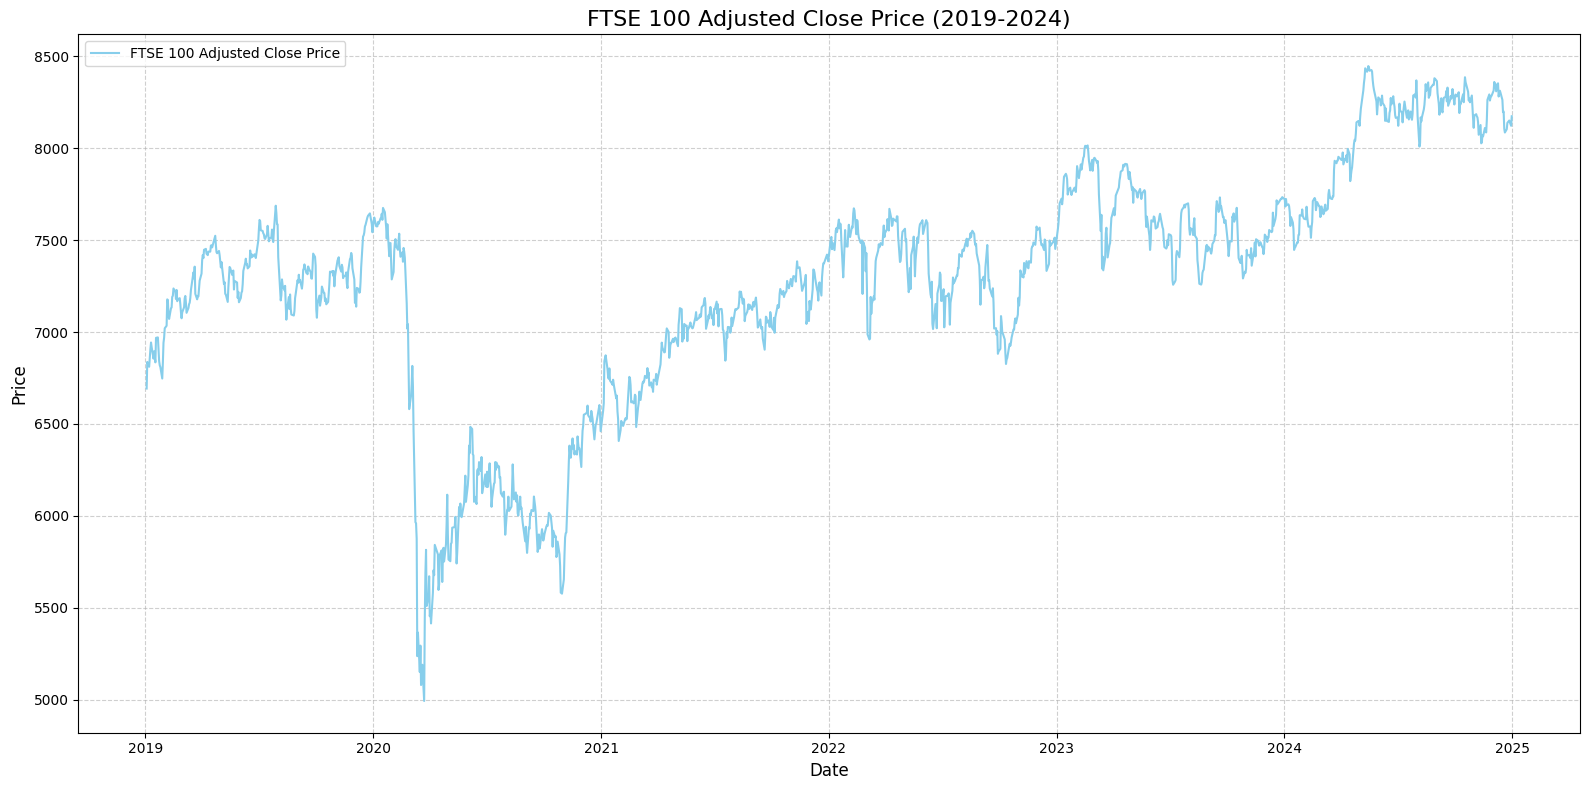

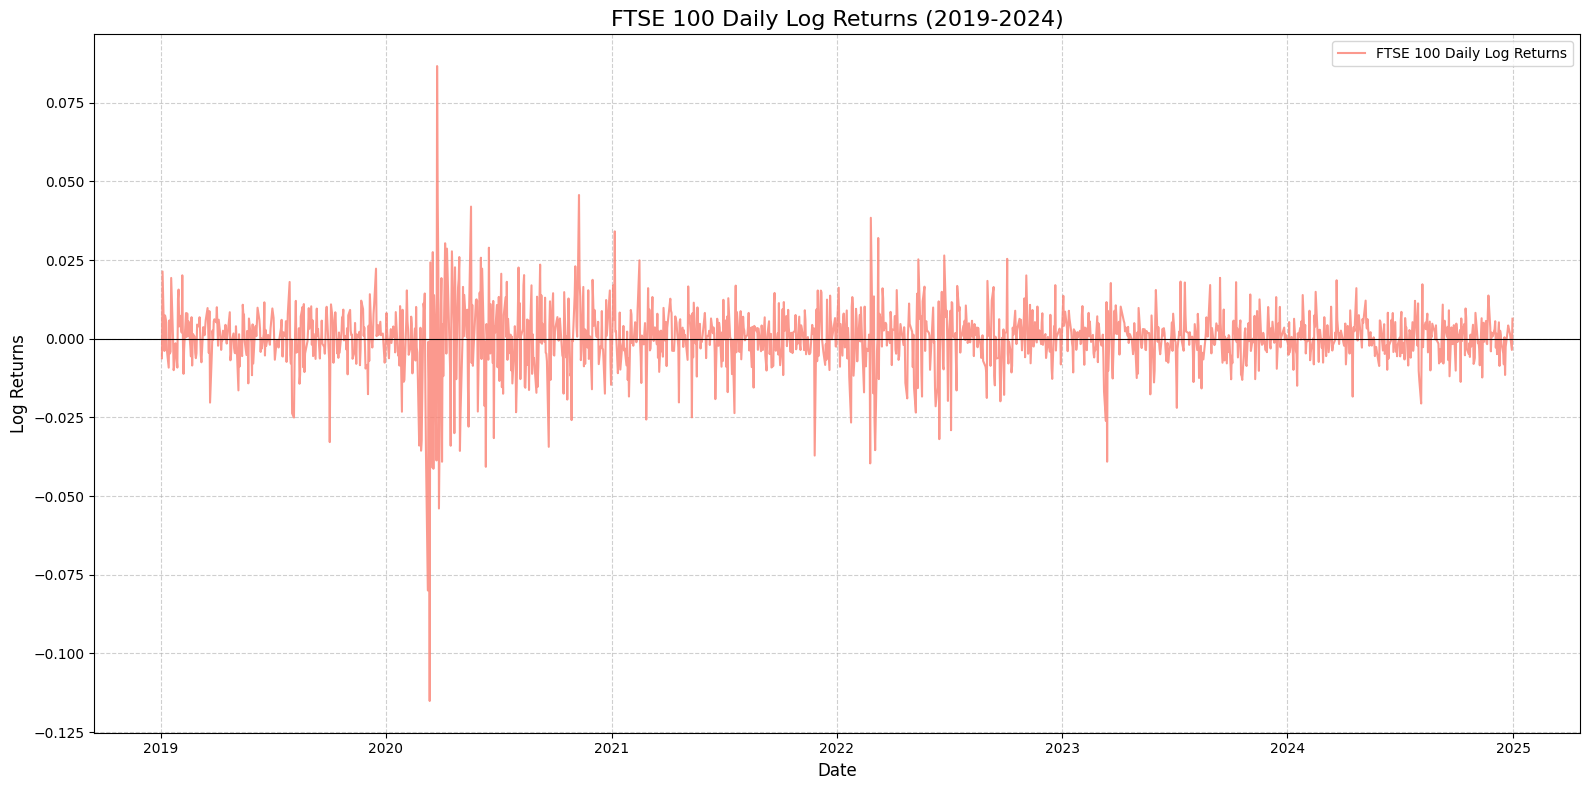

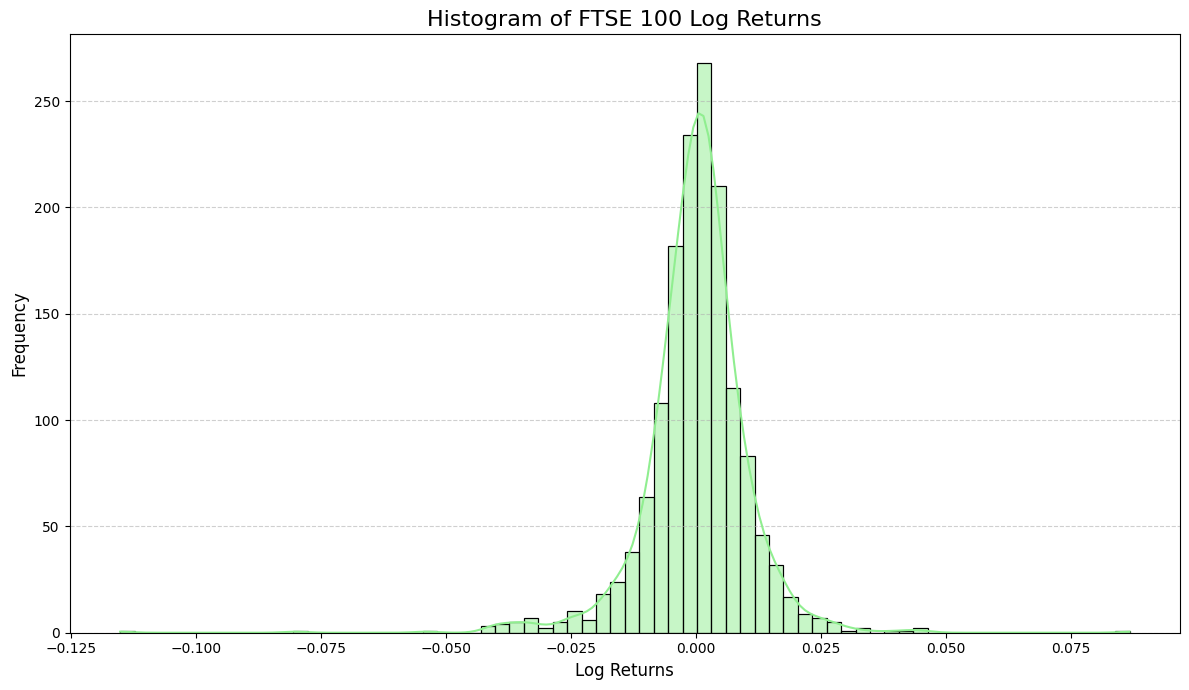

In [4]:
print("--- Starting Step 4: Data Visualization and Preparation for Modeling ---")

# --- Step 4.1: Visualize Prices and Returns ---
print("\n--- Generating Visualizations ---")

# Plot Adjusted Close Price
plt.figure(figsize=(16, 8))
plt.plot(ftse_data.index, ftse_data['Adj Close'], label='FTSE 100 Adjusted Close Price', color='skyblue')
plt.title('FTSE 100 Adjusted Close Price (2019-2024)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Plot Log Returns
plt.figure(figsize=(16, 8))
plt.plot(ftse_data.index, ftse_data['Log_Returns'], label='FTSE 100 Daily Log Returns', color='salmon', alpha=0.8)
plt.title('FTSE 100 Daily Log Returns (2019-2024)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log Returns', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linestyle='-', linewidth=0.8) # Add a horizontal line at 0 for reference
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Plot histogram of returns (to check for distribution characteristics, e.g., fat tails)
plt.figure(figsize=(12, 7))
sns.histplot(ftse_data['Log_Returns'], bins=70, kde=True, color='lightgreen', edgecolor='black')
plt.title('Histogram of FTSE 100 Log Returns', fontsize=16)
plt.xlabel('Log Returns', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- Step 4.2: Save Processed Data ---
output_filename = "ftse100_processed_data_for_volatility.csv"
ftse_data.to_csv(output_filename)

### ARIMA - Stationarity Check and ACF/PACF Analysis

--- Starting Step 5.1: ARIMA - Stationarity Check and ACF/PACF Analysis ---

Training data for ARIMA: 1210 samples (from 2019-01-03 to 2023-10-19)
Testing data for ARIMA: 303 samples (from 2023-10-20 to 2024-12-31)

--- Performing Augmented Dickey-Fuller (ADF) Test on Training Data ---
|                             | 0           |
|:----------------------------|:------------|
| Test Statistic              | -7.80355    |
| p-value                     | 7.38372e-12 |
| #Lags Used                  | 20          |
| Number of Observations Used | 1189        |
| Critical Value (1%)         | -3.43586    |
| Critical Value (5%)         | -2.86397    |
| Critical Value (10%)        | -2.56807    |

Conclusion: The p-value is <= 0.05. We can reject the null hypothesis.
           The Log_Returns series appears to be stationary.

--- Generating ACF and PACF Plots for Training Data ---


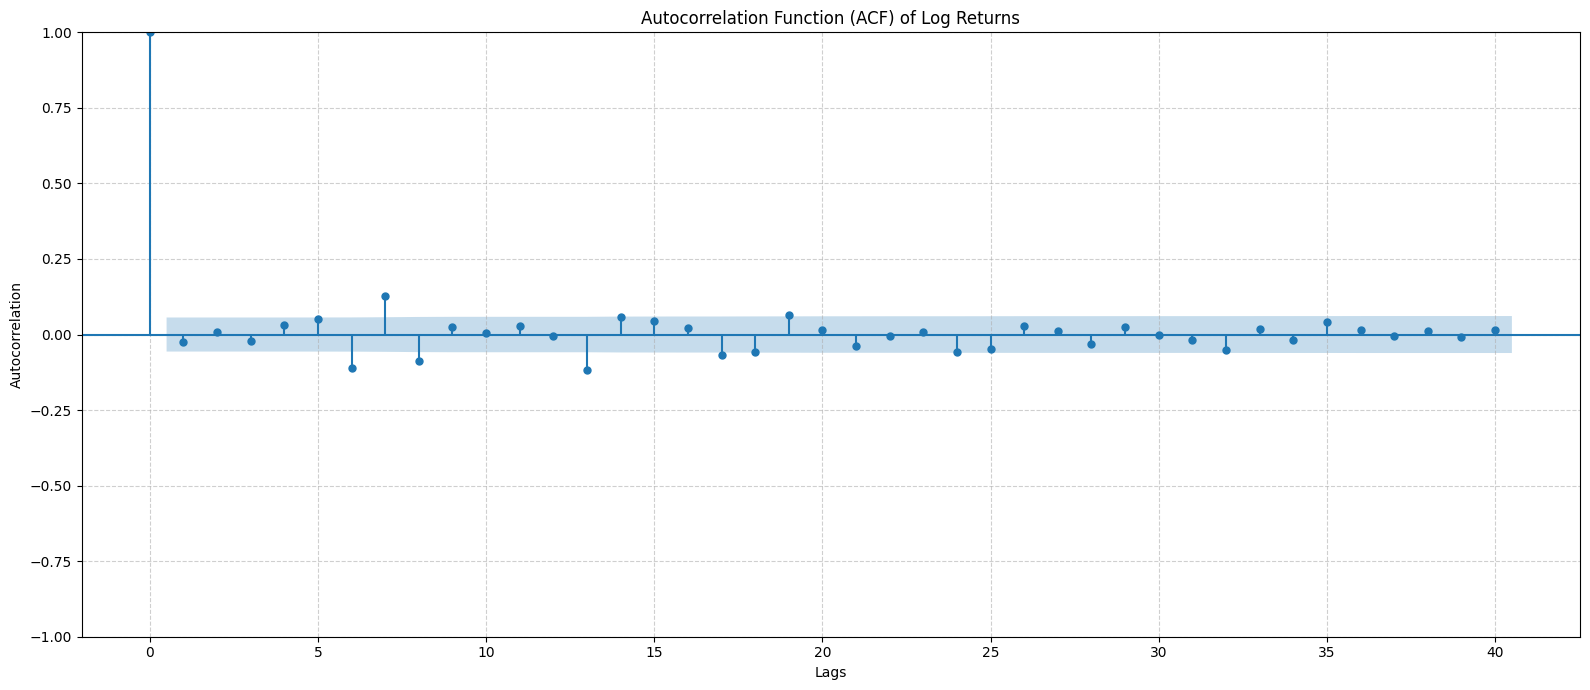

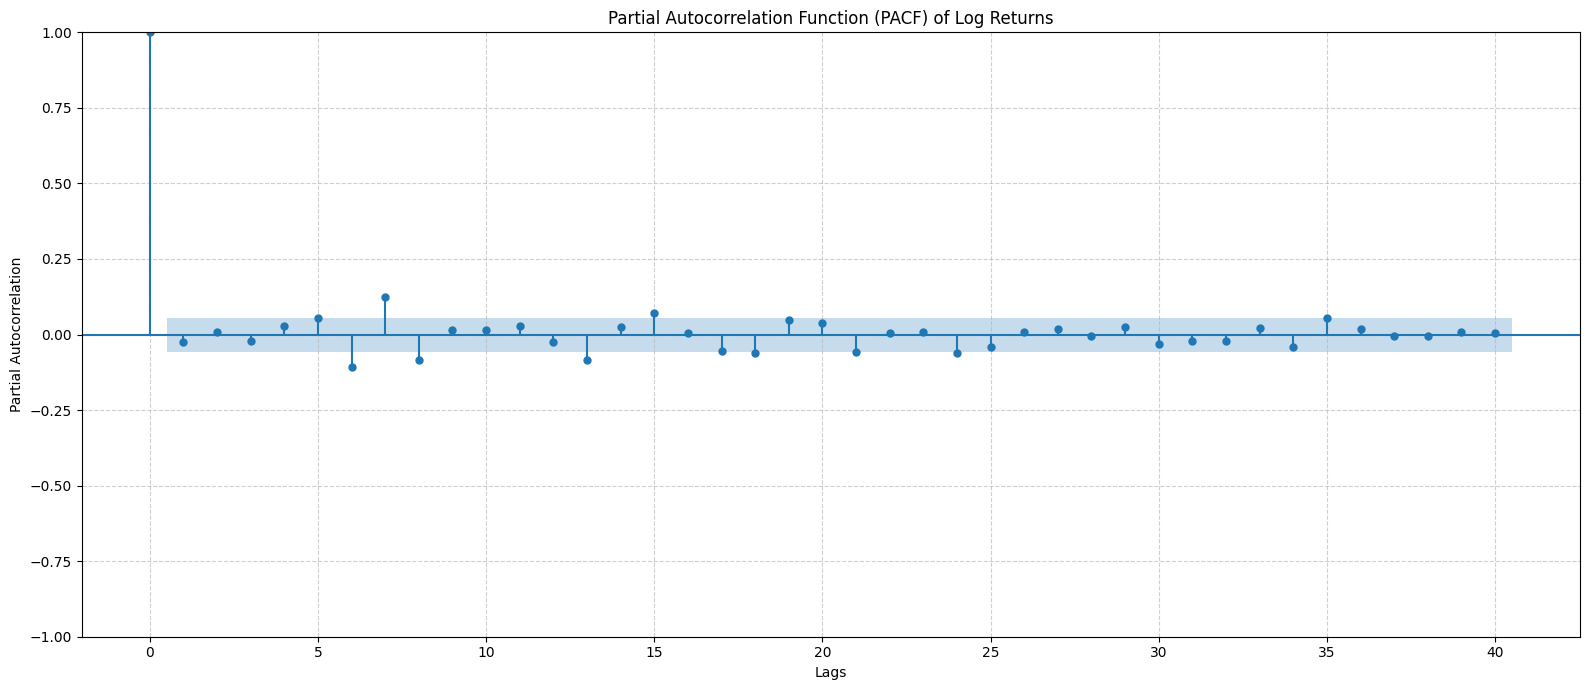

In [5]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("--- Starting Step 5.1: ARIMA - Stationarity Check and ACF/PACF Analysis ---")
returns_series = ftse_data['Log_Returns']

train_size = int(len(returns_series) * 0.8)
train_data = returns_series.iloc[:train_size]
test_data = returns_series.iloc[train_size:]

print(f"\nTraining data for ARIMA: {len(train_data)} samples (from {train_data.index.min().strftime('%Y-%m-%d')} to {train_data.index.max().strftime('%Y-%m-%d')})")
print(f"Testing data for ARIMA: {len(test_data)} samples (from {test_data.index.min().strftime('%Y-%m-%d')} to {test_data.index.max().strftime('%Y-%m-%d')})")


# --- Step 5.1.2: Perform Augmented Dickey-Fuller (ADF) Test for Stationarity ---
print("\n--- Performing Augmented Dickey-Fuller (ADF) Test on Training Data ---")
adf_test_result = adfuller(train_data)
adf_output = pd.Series(adf_test_result[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key, value in adf_test_result[4].items():
    adf_output[f'Critical Value ({key})'] = value
print(adf_output.to_markdown(numalign="left", stralign="left"))

if adf_output['p-value'] <= 0.05:
    print("\nConclusion: The p-value is <= 0.05. We can reject the null hypothesis.")
    print("           The Log_Returns series appears to be stationary.")
else:
    print("\nConclusion: The p-value is > 0.05. We cannot reject the null hypothesis.")
    print("           The Log_Returns series may not be stationary. Differencing (d>0) might be needed.")

# --- Step 5.1.3: Generate ACF and PACF Plots ---
print("\n--- Generating ACF and PACF Plots for Training Data ---")

# ACF plot
plt.figure(figsize=(16, 7))
plot_acf(train_data, lags=40, ax=plt.gca(), title='Autocorrelation Function (ACF) of Log Returns')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# PACF plot
plt.figure(figsize=(16, 7))
plot_pacf(train_data, lags=40, ax=plt.gca(), title='Partial Autocorrelation Function (PACF) of Log Returns')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## ARIMA - Model Fitting, Prediction, and Evaluation

In [6]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 6.0 MB/s eta 0:00:00


--- Starting Step 5.2: ARIMA - Model Fitting, Prediction, and Evaluation ---

Confirming Training data size: 1210
Confirming Testing data size: 303

--- Finding optimal ARIMA orders (p,d,q) using auto_arima ---
This step can take a few minutes...
Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-7396.971, Time=2.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-7400.650, Time=0.40 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-7399.443, Time=0.78 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-7399.428, Time=0.65 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-7398.724, Time=0.46 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0]          
Total fit time: 4.355 seconds

Optimal ARIMA Order (p,d,q): (0, 0, 0)
Best AIC: -7400.650170483683
Best BIC: -7395.551794845092

--- Fitting ARIMA(0, 0, 0) model on training data ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:            Log_Returns   No. Observations:                 1210
Model:                          ARIMA   Log Likelihood                3701.362
Date:                Sun, 04 Jan 2026   AIC                          -7398.724
Time:                        17:25:44   BIC                          -7388.527
Sample:                             0   HQIC                         -7394.884
                               - 1210                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       8.397e-05      0.000      0.247      0.805      -0.001       0.001
sigma2         0.0001   1.87e-06     68.774      0.000       0.000       0.000
Ljung-Box (L1) (Q):           

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


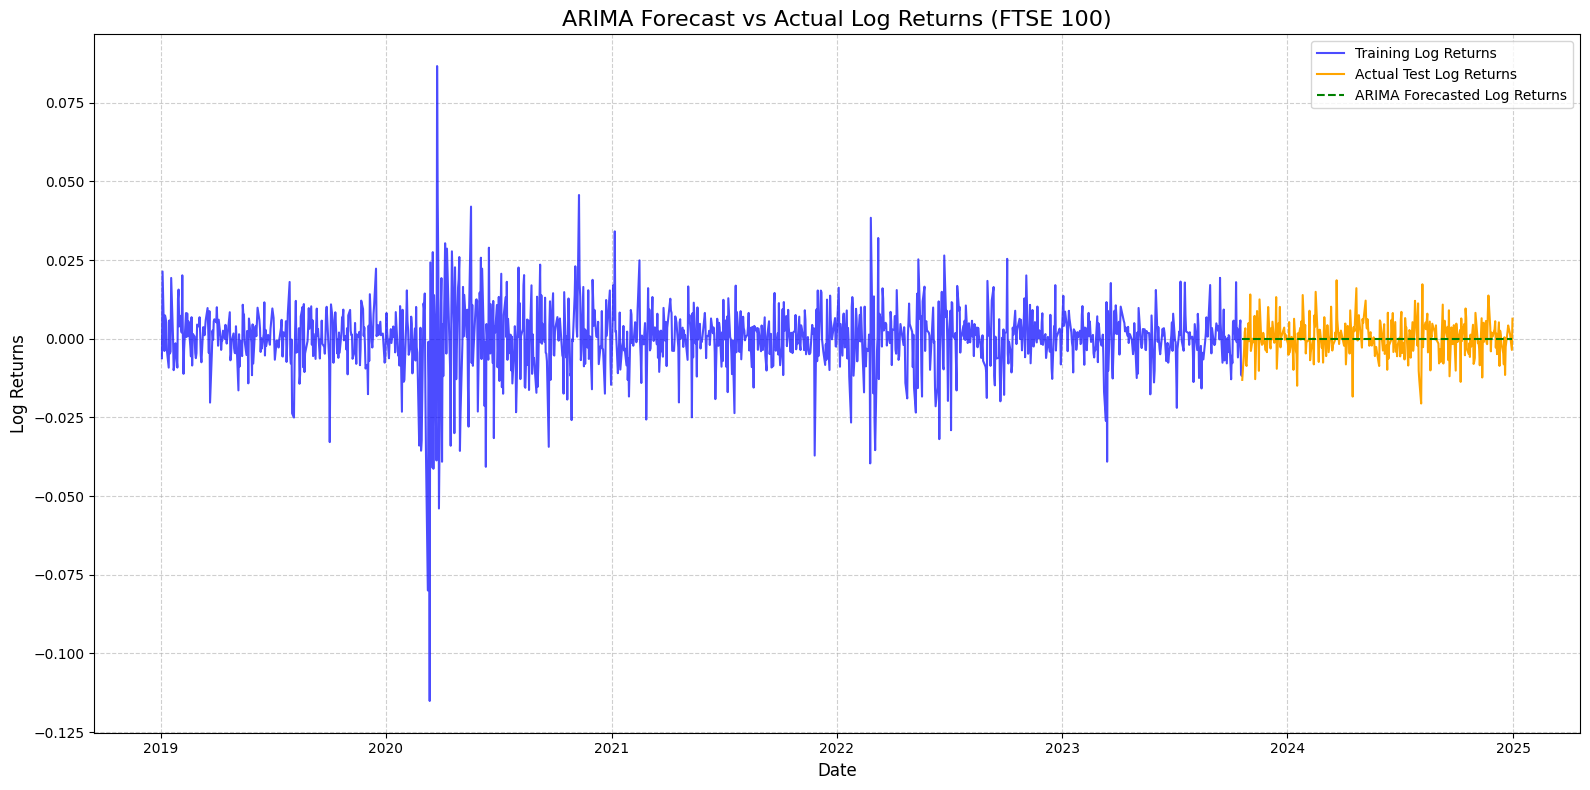

In [7]:
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from math import sqrt

print("--- Starting Step 5.2: ARIMA - Model Fitting, Prediction, and Evaluation ---")
returns_series = ftse_data['Log_Returns']

train_size = int(len(returns_series) * 0.8)
train_data = returns_series.iloc[:train_size]
test_data = returns_series.iloc[train_size:]

print(f"\nConfirming Training data size: {len(train_data)}")
print(f"Confirming Testing data size: {len(test_data)}")

# --- Step 5.2.2: Find Optimal ARIMA Orders using auto_arima ---
print("\n--- Finding optimal ARIMA orders (p,d,q) using auto_arima ---")
print("This step can take a few minutes...")
optimal_arima_model = pm.auto_arima(train_data,
                                    start_p=1, start_q=1,
                                    max_p=5, max_q=5, # Search up to order 5 for p and q
                                    d=0, # d=0 based on ADF test
                                    seasonal=False, # No seasonality for daily returns
                                    trace=True, # Show model fitting progress
                                    error_action='ignore',
                                    suppress_warnings=True,
                                    stepwise=True)

print("\nOptimal ARIMA Order (p,d,q):", optimal_arima_model.order)
print("Best AIC:", optimal_arima_model.aic())
print("Best BIC:", optimal_arima_model.bic())


# --- Step 5.2.3: Fit the ARIMA Model ---
# Using the optimal order found by auto_arima
arima_order = optimal_arima_model.order
print(f"\n--- Fitting ARIMA{arima_order} model on training data ---")
model = ARIMA(train_data, order=arima_order)
model_fit = model.fit()

print("\nARIMA Model Summary:")
print(model_fit.summary().as_text())


# --- Step 5.2.4: Make Predictions ---
print(f"\n--- Generating {len(test_data)} ARIMA predictions on test data ---")
# Forecast out-of-sample
forecast_steps = len(test_data)
arima_predictions = model_fit.forecast(steps=forecast_steps)

# Assign index to predictions for easy comparison
arima_predictions.index = test_data.index

print("\nFirst 5 ARIMA predictions:")
print(arima_predictions.head().to_markdown(numalign="left", stralign="left"))


# --- Step 5.2.5: Evaluate Model Performance ---
print("\n--- Evaluating ARIMA Model Performance ---")

# Root Mean Squared Error (RMSE)
rmse = sqrt(mean_squared_error(test_data, arima_predictions))
print(f"RMSE (Root Mean Squared Error): {rmse:.6f}")

# Mean Squared Error (MSE)
mse = mean_squared_error(test_data, arima_predictions)
print(f"MSE (Mean Squared Error): {mse:.6f}")

mape = np.mean(np.abs((test_data - arima_predictions) / test_data)) * 100
# A more robust MAPE, handling potential zero actuals if they occur
mape_robust = mean_absolute_percentage_error(test_data, arima_predictions) * 100
print(f"MAPE (Mean Absolute Percentage Error): {mape_robust:.4f}%") # Using sklearn's robust MAPE


# --- Step 5.2.6: Visualize Predictions vs Actuals ---
print("\n--- Visualizing ARIMA Predictions vs Actuals ---")
plt.figure(figsize=(16, 8))
plt.plot(train_data.index, train_data, label='Training Log Returns', color='blue', alpha=0.7)
plt.plot(test_data.index, test_data, label='Actual Test Log Returns', color='orange')
plt.plot(arima_predictions.index, arima_predictions, label='ARIMA Forecasted Log Returns', color='green', linestyle='--')
plt.title('ARIMA Forecast vs Actual Log Returns (FTSE 100)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log Returns', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## GARCH Model - Fitting and Forecasting Volatility

In [8]:
!pip install arch


--- GARCH - Hyperparameter Tuning ---

--- Running 5 GARCH experiments ---
  Evaluating GARCH(1,1) with Zero mean and StudentsT distribution...
  Finished GARCH(1,1) - Baseline. RMSE: 0.004839, MAPE: 595.8629%, Time: 37.66s
  Evaluating GARCH(1,2) with Zero mean and StudentsT distribution...
  Finished GARCH(1,2). RMSE: 0.004800, MAPE: 581.0569%, Time: 28.76s
  Evaluating GARCH(2,1) with Zero mean and StudentsT distribution...
  Finished GARCH(2,1). RMSE: 0.004839, MAPE: 595.7981%, Time: 29.60s
  Evaluating GARCH(2,2) with Zero mean and StudentsT distribution...
  Finished GARCH(2,2). RMSE: 0.004809, MAPE: 591.7429%, Time: 38.86s
  Evaluating GARCH(1,0) with Zero mean and StudentsT distribution...
  Finished GARCH(1,0) - Pure ARCH(1) like. RMSE: 0.006452, MAPE: 754.0959%, Time: 17.70s

--- All GARCH experiments completed in 152.58 seconds. ---

--- GARCH Hyperparameter Tuning Results Summary ---
| Experiment                     | p   | q   | RMSE     | MSE     | MAPE    | Time_Taken_s

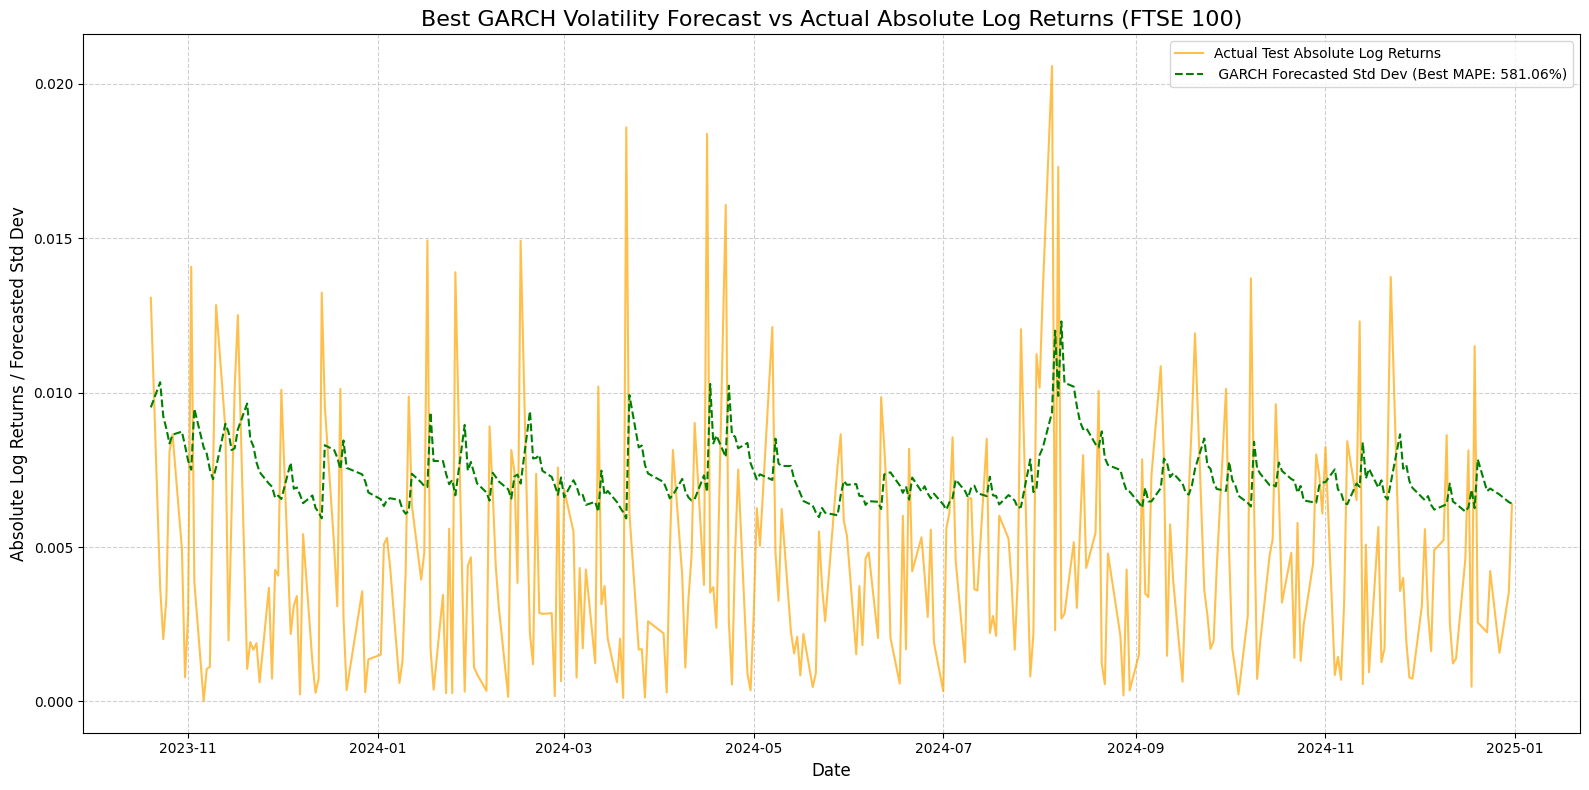

In [9]:
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from math import sqrt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import time
warnings.filterwarnings("ignore")


print("\n--- GARCH - Hyperparameter Tuning ---")

returns_series = ftse_data['Log_Returns']

train_size = int(len(returns_series) * 0.8)
train_data_initial = returns_series.iloc[:train_size]
test_data = returns_series.iloc[train_size:]

scale_factor = 10000
train_data_initial_scaled = train_data_initial * scale_factor
test_data_scaled = test_data * scale_factor


# --- Define a function for performing and evaluating a GARCH forecast ---
def evaluate_garch_model(p_order, q_order, mean_model='Zero', vol_dist='StudentsT',
                                 initial_train_data_scaled=None, test_data_scaled=None,
                                 original_test_data=None, scale_factor=1):

    print(f"  Evaluating GARCH({p_order},{q_order}) with {mean_model} mean and {vol_dist} distribution...")

    if initial_train_data_scaled is None or test_data_scaled is None or original_test_data is None:
        raise ValueError("Initial training data, test data, and original test data must be provided.")

    garch_predictions_scaled = []
    history_scaled = initial_train_data_scaled.tolist()

    warnings.filterwarnings("ignore", category=UserWarning, module='arch.univariate.base')

    for i in range(len(test_data_scaled)):
        current_history_series = pd.Series(history_scaled)
        am = arch_model(current_history_series, mean=mean_model, vol='GARCH', p=p_order, q=q_order, dist=vol_dist)
        res = am.fit(disp='off')

        forecast = res.forecast(horizon=1, reindex=False)
        variance_column_name = forecast.variance.columns[0]
        next_day_variance_scaled = forecast.variance.iloc[0][variance_column_name]
        garch_predictions_scaled.append(np.sqrt(next_day_variance_scaled))

        history_scaled.append(test_data_scaled.iloc[i])

    warnings.filterwarnings("default", category=UserWarning, module='arch.univariate.base')

    garch_std_dev_scaled = np.array(garch_predictions_scaled)
    garch_std_dev = garch_std_dev_scaled / scale_factor
    garch_std_dev_series = pd.Series(garch_std_dev, index=original_test_data.index)

    actual_absolute_returns = np.abs(original_test_data)
    rmse = sqrt(mean_squared_error(actual_absolute_returns, garch_std_dev_series))
    mse = mean_squared_error(actual_absolute_returns, garch_std_dev_series)
    mape = mean_absolute_percentage_error(actual_absolute_returns, garch_std_dev_series) * 100

    return rmse, mse, mape, garch_std_dev_series


tuning_experiments = [
    {'p': 1, 'q': 1, 'description': 'GARCH(1,1) - Baseline'},
    {'p': 1, 'q': 2, 'description': 'GARCH(1,2)'},
    {'p': 2, 'q': 1, 'description': 'GARCH(2,1)'},
    {'p': 2, 'q': 2, 'description': 'GARCH(2,2)'},
    {'p': 1, 'q': 0, 'description': 'GARCH(1,0) - Pure ARCH(1) like'},
]

results = []
best_mape = float('inf')
best_garch_forecast = None
best_experiment_params = None

print(f"\n--- Running {len(tuning_experiments)} GARCH experiments ---")
total_start_time = time.time()

for i, params in enumerate(tuning_experiments):
    exp_start_time = time.time()
    rmse, mse, mape, garch_forecast_series = evaluate_garch_model(
        p_order=params['p'],
        q_order=params['q'],
        initial_train_data_scaled=train_data_initial_scaled,
        test_data_scaled=test_data_scaled,
        original_test_data=test_data,
        scale_factor=scale_factor
    )
    exp_end_time = time.time()

    results.append({
        'Experiment': params['description'],
        'p': params['p'], 'q': params['q'],
        'RMSE': rmse, 'MSE': mse, 'MAPE': mape,
        'Time_Taken_s': exp_end_time - exp_start_time
    })

    if mape < best_mape:
        best_mape = mape
        best_garch_forecast = garch_forecast_series
        best_experiment_params = params

    print(f"  Finished {params['description']}. RMSE: {rmse:.6f}, MAPE: {mape:.4f}%, Time: {exp_end_time - exp_start_time:.2f}s")


total_end_time = time.time()
print(f"\n--- All GARCH experiments completed in {total_end_time - total_start_time:.2f} seconds. ---")


# --- Print Summary of Results ---
print("\n--- GARCH Hyperparameter Tuning Results Summary ---")
results_df = pd.DataFrame(results)
print(results_df.round(6).to_markdown(index=False, numalign="left", stralign="left"))

print(f"\nBest GARCH Model (based on MAPE): {best_experiment_params}")
print(f"Best MAPE achieved: {best_mape:.4f}%")


# --- Visualize Best Model's Predictions ---
if best_garch_forecast is not None:
    print("\n--- Visualizing Predictions of the Best GARCH Model (based on MAPE) ---")
    plt.figure(figsize=(16, 8))
    plt.plot(test_data.index, np.abs(test_data), label='Actual Test Absolute Log Returns', color='orange', alpha=0.7)
    plt.plot(best_garch_forecast.index, best_garch_forecast, label=f' GARCH Forecasted Std Dev (Best MAPE: {best_mape:.2f}%)', color='green', linestyle='--')
    plt.title('Best GARCH Volatility Forecast vs Actual Absolute Log Returns (FTSE 100)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Absolute Log Returns / Forecasted Std Dev', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

##  LSTM - Data Preparation (Scaling and Sequencing)

In [10]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n--- Starting Step 7.1: LSTM - Data Preparation for Volatility Forecasting (Scaling and Sequencing) ---")

returns_series = ftse_data['Log_Returns']

# --- Step 7.1.1: Define Volatility Target and Scale ---
print("\n--- Defining volatility target as absolute log returns and scaling data (MinMaxScaler) ---")
volatility_target_series = np.abs(returns_series) # Using absolute returns as a proxy for volatility

scaler_vol = MinMaxScaler(feature_range=(-1, 1))
scaled_volatility = scaler_vol.fit_transform(volatility_target_series.values.reshape(-1, 1))

print(f"Original Volatility Target Min: {volatility_target_series.min():.6f}, Max: {volatility_target_series.max():.6f}")
print(f"Scaled Volatility Target Min: {scaled_volatility.min():.6f}, Max: {scaled_volatility.max():.6f}")

# --- Step 7.1.2: Create Sequences for LSTM ---
def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:(i + n_steps), 0])
        y.append(data[i + n_steps, 0])
    return np.array(X), np.array(y)

print(f"\n`create_sequences` function defined. Will be used for dynamic n_steps in tuning.")

# Store scaled_volatility, scaler_vol, and ftse_data.index for later use in the tuning loop
# The actual sequences and train/test split will be done inside the tuning loop
# to allow dynamic n_steps.
lstm_scaled_volatility = scaled_volatility
lstm_scaler_vol = scaler_vol
lstm_ftse_data_index = ftse_data.index

print("Volatility data scaled and relevant variables stored for LSTM tuning.")


--- Starting Step 7.1: LSTM - Data Preparation for Volatility Forecasting (Scaling and Sequencing) ---

--- Defining volatility target as absolute log returns and scaling data (MinMaxScaler) ---
Original Volatility Target Min: 0.000000, Max: 0.115117
Scaled Volatility Target Min: -1.000000, Max: 1.000000

`create_sequences` function defined. Will be used for dynamic n_steps in tuning.
Volatility data scaled and relevant variables stored for LSTM tuning.


## LSTM - Model Building, Training, Prediction, and Evaluation


--- Starting Step 7.4: LSTM - Hyperparameter Tuning for Volatility Forecast ---

--- Running Experiment 1/6 ---

--- Evaluating with n_steps=60, units=50, dropout=0.2, batch_size=32 ---
  RMSE: 0.003913, MSE: 0.000015, MAPE: 258.6557%, Time: 42.43s

--- Running Experiment 2/6 ---

--- Evaluating with n_steps=30, units=50, dropout=0.2, batch_size=32 ---
  RMSE: 0.003890, MSE: 0.000015, MAPE: 377.7622%, Time: 30.31s

--- Running Experiment 3/6 ---

--- Evaluating with n_steps=90, units=50, dropout=0.2, batch_size=32 ---
  RMSE: 0.003882, MSE: 0.000015, MAPE: 256.1880%, Time: 79.64s

--- Running Experiment 4/6 ---

--- Evaluating with n_steps=60, units=75, dropout=0.2, batch_size=32 ---
  RMSE: 0.003951, MSE: 0.000016, MAPE: 270.9374%, Time: 36.43s

--- Running Experiment 5/6 ---

--- Evaluating with n_steps=60, units=50, dropout=0.1, batch_size=32 ---
  RMSE: 0.003871, MSE: 0.000015, MAPE: 243.1145%, Time: 30.31s

--- Running Experiment 6/6 ---

--- Evaluating with n_steps=60, units=50,

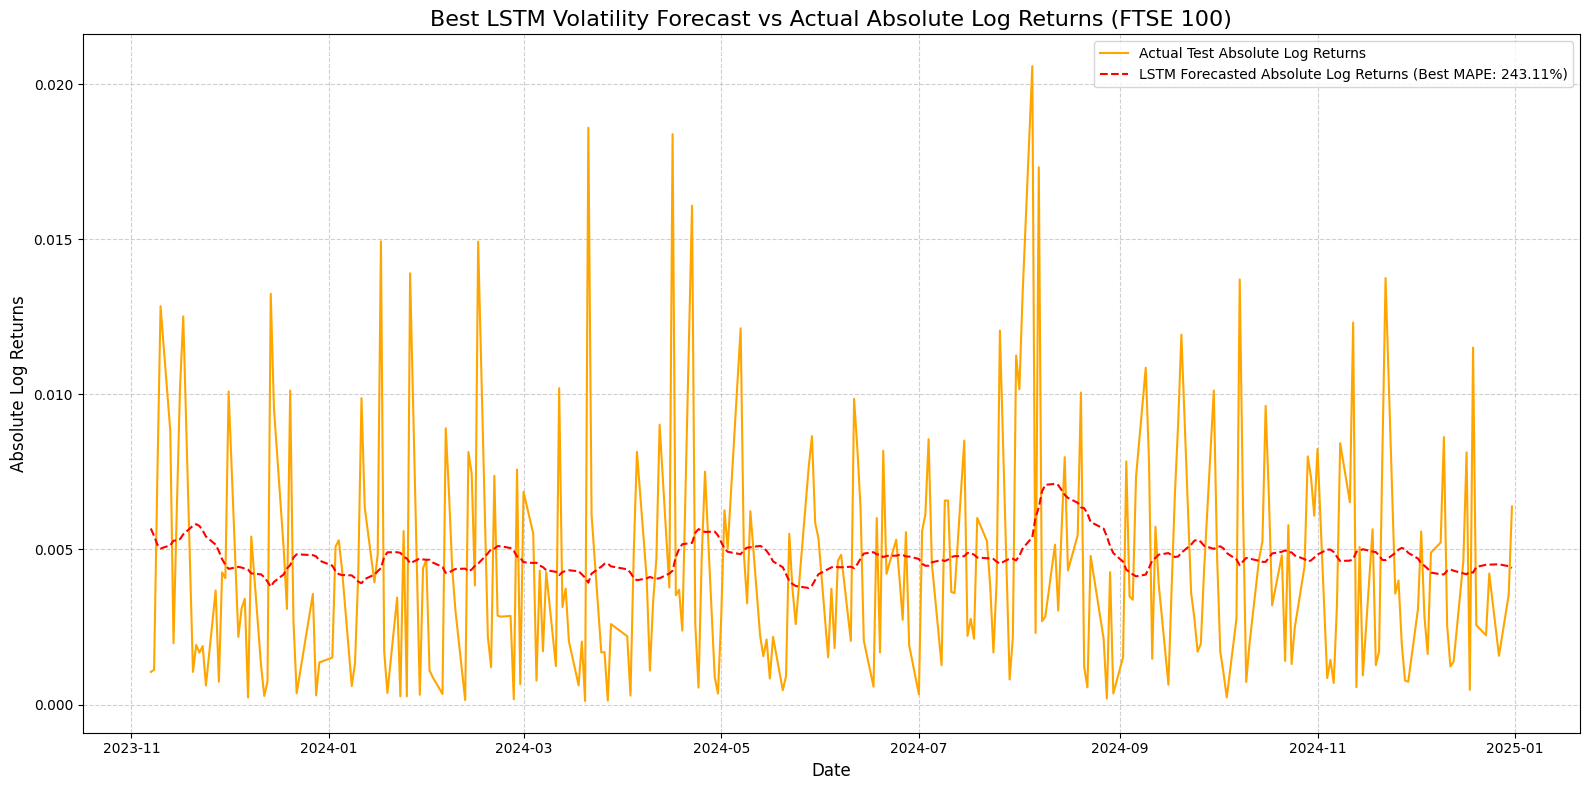

In [11]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from math import sqrt
import time

print("\n--- Starting Step 7.4: LSTM - Hyperparameter Tuning for Volatility Forecast ---")

# Ensure these variables are globally available from previous steps (specifically cell 2438ce7e-8fef-47a5-a365-678c1bc30239)
# lstm_scaled_volatility, lstm_scaler_vol, lstm_ftse_data_index, create_sequences (function)

# --- Define a function for building, training, and evaluating LSTM ---
def evaluate_lstm_volatility_model(scaled_volatility_data, scaler_object, original_index, current_n_steps,
                                   lstm_units, dropout_rate, batch_size, epochs=100, patience=10):
    print(f"\n--- Evaluating with n_steps={current_n_steps}, units={lstm_units}, dropout={dropout_rate}, batch_size={batch_size} ---")
    start_time = time.time()

    # Create sequences for the current n_steps
    X_vol, y_vol = create_sequences(scaled_volatility_data, current_n_steps)
    X_vol = X_vol.reshape(X_vol.shape[0], X_vol.shape[1], 1)

    # Split into Training and Testing Sets
    train_size_seq_vol = int(len(X_vol) * 0.8)
    X_train_vol, X_test_vol = X_vol[:train_size_seq_vol], X_vol[train_size_seq_vol:]
    y_train_vol, y_test_vol = y_vol[:train_size_seq_vol], y_vol[train_size_seq_vol:]

    # 1. Build the LSTM Model
    model = Sequential()
    model.add(LSTM(units=lstm_units, return_sequences=True, input_shape=(current_n_steps, 1)))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units=lstm_units, return_sequences=False))
    model.add(Dropout(dropout_rate))
    model.add(Dense(units=1))
    model.compile(optimizer='adam', loss='mean_squared_error')

    # 2. Train the LSTM Model
    early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, verbose=0)
    model.fit(X_train_vol, y_train_vol, epochs=epochs, batch_size=batch_size, validation_split=0.1,
              callbacks=[early_stopping], verbose=0) # verbose=0 to suppress epoch output for cleaner tuning results

    # 3. Make Predictions
    lstm_predictions_scaled_vol = model.predict(X_test_vol, verbose=0)
    lstm_predictions_vol = scaler_object.inverse_transform(lstm_predictions_scaled_vol)
    y_test_actual_vol = scaler_object.inverse_transform(y_test_vol.reshape(-1, 1))

    # 4. Correct Index Alignment
    # Calculate the starting index in the original ftse_data for the test set of sequences
    # This takes into account the look-back period (n_steps) and the train-test split for sequences
    start_index_in_original_data = len(original_index) - len(scaled_volatility_data) + len(X_train_vol) + current_n_steps # Corrected logic

    lstm_vol_test_dates = original_index[start_index_in_original_data : start_index_in_original_data + len(y_test_actual_vol)]


    y_test_actual_series_vol = pd.Series(y_test_actual_vol.flatten(), index=lstm_vol_test_dates)
    lstm_predictions_series_vol = pd.Series(lstm_predictions_vol.flatten(), index=lstm_vol_test_dates)

    # 5. Evaluate Model Performance
    rmse = sqrt(mean_squared_error(y_test_actual_series_vol, lstm_predictions_series_vol))
    mse = mean_squared_error(y_test_actual_series_vol, lstm_predictions_series_vol)
    mape = mean_absolute_percentage_error(y_test_actual_series_vol, lstm_predictions_series_vol) * 100

    end_time = time.time()
    print(f"  RMSE: {rmse:.6f}, MSE: {mse:.6f}, MAPE: {mape:.4f}%, Time: {end_time - start_time:.2f}s")
    return rmse, mse, mape, model, lstm_predictions_series_vol, y_test_actual_series_vol


# --- Hyperparameter Combinations ---
tuning_experiments = []

# Experiment 1: Baseline (from previous best for comparison)
tuning_experiments.append({'n_steps': 60, 'units': 50, 'dropout': 0.2, 'batch_size': 32})

# Experiment 2: Shorter look-back window
tuning_experiments.append({'n_steps': 30, 'units': 50, 'dropout': 0.2, 'batch_size': 32})

# Experiment 3: Longer look-back window
tuning_experiments.append({'n_steps': 90, 'units': 50, 'dropout': 0.2, 'batch_size': 32})

# Experiment 4: More LSTM units
tuning_experiments.append({'n_steps': 60, 'units': 75, 'dropout': 0.2, 'batch_size': 32})

# Experiment 5: Less Dropout
tuning_experiments.append({'n_steps': 60, 'units': 50, 'dropout': 0.1, 'batch_size': 32})

# Experiment 6: Different Batch Size
tuning_experiments.append({'n_steps': 60, 'units': 50, 'dropout': 0.2, 'batch_size': 64})


results = []
best_mape = float('inf')
best_experiment = None
best_predictions = None
best_actuals = None
best_model = None


# --- Run Experiments ---
for i, params in enumerate(tuning_experiments):
    print(f"\n--- Running Experiment {i+1}/{len(tuning_experiments)} ---")
    # Dynamically use the n_steps from the current experiment for the model
    current_n_steps = params['n_steps']

    rmse, mse, mape, model_trained, predictions_series, actuals_series = evaluate_lstm_volatility_model(
        scaled_volatility_data=lstm_scaled_volatility,
        scaler_object=lstm_scaler_vol,
        original_index=lstm_ftse_data_index,
        current_n_steps=current_n_steps, # Pass the current n_steps to the function
        lstm_units=params['units'],
        dropout_rate=params['dropout'],
        batch_size=params['batch_size']
    )
    results.append({'Experiment': i+1, **params, 'RMSE': rmse, 'MSE': mse, 'MAPE': mape})

    # Track the best model based on MAPE
    if mape < best_mape:
        best_mape = mape
        best_experiment = params
        best_predictions = predictions_series
        best_actuals = actuals_series
        best_model = model_trained

# --- Print Summary of Results ---
print("\n--- Hyperparameter Tuning Results Summary ---")
results_df = pd.DataFrame(results)
print(results_df.round(6).to_markdown(index=False, numalign="left", stralign="left"))

print(f"\nBest Experiment (based on MAPE): {best_experiment}")
print(f"Best MAPE achieved: {best_mape:.4f}%")


# --- Visualize Best Model's Predictions ---
if best_predictions is not None and best_actuals is not None:
    print("\n--- Visualizing Predictions of the Best LSTM Model (based on MAPE) ---")
    plt.figure(figsize=(16, 8))
    plt.plot(best_actuals.index, best_actuals, label='Actual Test Absolute Log Returns', color='orange')
    plt.plot(best_predictions.index, best_predictions, label=f'LSTM Forecasted Absolute Log Returns (Best MAPE: {best_mape:.2f}%)', color='red', linestyle='--')
    plt.title('Best LSTM Volatility Forecast vs Actual Absolute Log Returns (FTSE 100)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Absolute Log Returns', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()